# Compare AI vs Human Research Proposals

This notebook implements the diversity analysis comparing AI-generated proposals against human-written proposals.

## Analysis Overview:
- **2.1.1**: Within-group pairwise diversity
- **2.1.2**: Centroid dispersion metric
- **2.1.3**: Nearest-neighbor outlier detection

Each analysis includes statistical tests (Mann-Whitney U, Cliff's delta, permutation tests) and visualizations.

## Setup and Imports

In [1]:
import sys
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NLP and embeddings
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from scipy.spatial.distance import cdist
from tqdm import tqdm

# Statistics
from scipy import stats
from scipy.stats import mannwhitneyu
import itertools

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")
print(f"✓ Working directory: {os.getcwd()}")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

✓ Imports successful
✓ Working directory: /Users/eveyhuang/Documents/NICO/human-AI-proposal-comparison
✓ PyTorch version: 2.6.0
✓ CUDA available: False


## Helper Functions

In [2]:
def cliffs_delta(group1, group2):
    """
    Calculate Cliff's Delta effect size.
    
    Interpretation:
    - |δ| < 0.147: negligible
    - |δ| < 0.33: small
    - |δ| < 0.474: medium
    - |δ| ≥ 0.474: large
    """
    n1, n2 = len(group1), len(group2)
    
    # Count pairs where group1 > group2 and group1 < group2
    dominance = 0
    for x in group1:
        for y in group2:
            if x > y:
                dominance += 1
            elif x < y:
                dominance -= 1
    
    delta = dominance / (n1 * n2)
    return delta

def interpret_cliffs_delta(delta):
    """Interpret Cliff's Delta magnitude"""
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return "negligible"
    elif abs_delta < 0.33:
        return "small"
    elif abs_delta < 0.474:
        return "medium"
    else:
        return "large"

def permutation_test(group1, group2, n_permutations=10000, random_state=42):
    """
    Perform permutation test for difference in means.
    """
    np.random.seed(random_state)
    
    # Observed difference
    obs_diff = np.mean(group1) - np.mean(group2)
    
    # Combine groups
    combined = np.concatenate([group1, group2])
    n1 = len(group1)
    
    # Permutation distribution
    perm_diffs = []
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        perm_group1 = combined[:n1]
        perm_group2 = combined[n1:]
        perm_diff = np.mean(perm_group1) - np.mean(perm_group2)
        perm_diffs.append(perm_diff)
    
    perm_diffs = np.array(perm_diffs)
    
    # Two-tailed p-value
    p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))
    
    return p_value, obs_diff, perm_diffs

print("✓ Helper functions defined")

✓ Helper functions defined


## Load Data

In [5]:
# Load AI proposals
ai_proposals_path = Path('data/ai-proposals/baseline')
ai_files = sorted(ai_proposals_path.glob('ai_proposals_baseline_complete_*.csv'))

if not ai_files:
    raise FileNotFoundError("No AI proposal files found. Run gen_proposals.ipynb first.")

# Use the most recent file
ai_df = pd.read_csv(ai_files[-1])
print(f"✓ Loaded AI proposals from: {ai_files[-1].name}")
print(f"  Shape: {ai_df.shape}")
print(f"  Models: {ai_df['model'].value_counts().to_dict()}")

# Load human proposals
human_proposals_path = Path('data/human-proposals')
human_files = list(human_proposals_path.glob('*.json'))

human_proposals = []
for file in human_files:
    with open(file, 'r') as f:
        data = json.load(f)
        
        # Handle different JSON structures
        if isinstance(data, list):
            # Case 1: JSON is a flat list of proposals
            for proposal in data:
                proposal['source_file'] = file.name
                human_proposals.append(proposal)
        elif 'proposals' in data:
            # Case 2: JSON has a 'proposals' key (most common structure)
            for proposal in data['proposals']:
                proposal['source_file'] = file.name
                human_proposals.append(proposal)
        else:
            # Case 3: JSON is a single proposal object
            data['source_file'] = file.name
            human_proposals.append(data)

human_df = pd.DataFrame(human_proposals)
print(f"\n✓ Loaded human proposals from {len(human_files)} files")
print(f"  Total proposals: {len(human_df)}")
print(f"  Source files: {human_df['source_file'].unique().tolist()}")

✓ Loaded AI proposals from: ai_proposals_baseline_complete_20260209_205423.csv
  Shape: (69, 10)
  Models: {'gpt-5.2': 23, 'gemini-3-pro-preview': 23, 'claude-opus-4-5': 23}

✓ Loaded human proposals from 2 files
  Total proposals: 23
  Source files: ['human-proposals-y1.json', 'human-proposals-y2.json']


## Prepare Proposal Texts

Combine all sections of proposals into full text for embedding.

In [7]:
def create_full_text(row, is_ai=True):
    """
    Create full proposal text from components.
    """
    if is_ai:
        # AI proposals structure
        sections = [
            f"Title: {row.get('title', '')}",
            f"Abstract: {row.get('abstract', '')}",
            f"Background: {row.get('background_and_significance', '')}",
            f"Research Questions: {row.get('research_questions_and_hypotheses', '')}",
            f"Methods: {row.get('methods_and_approach', '')}",
            f"Outcomes: {row.get('expected_outcomes_and_impact', '')}",
            f"Open Science: {row.get('open_science_and_reproducibility', '')}",
            f"Budget: {row.get('budget_and_resources', '')}"
        ]
    else:
        # Human proposals structure (based on actual JSON structure)
        sections = [
            f"Title: {row.get('proposal_title', row.get('title', ''))}",
            f"Abstract: {row.get('abstract', '')}",
            f"Full Proposal: {row.get('full_draft', row.get('full_text', row.get('full_proposal', '')))}"
        ]
    
    # Filter out empty sections and join
    text = " ".join([s for s in sections if s.split(': ', 1)[1].strip()])
    return text

# Create full texts
ai_df['full_text'] = ai_df.apply(lambda row: create_full_text(row, is_ai=True), axis=1)
human_df['full_text'] = human_df.apply(lambda row: create_full_text(row, is_ai=False), axis=1)

# Add group labels
ai_df['group'] = 'AI'
human_df['group'] = 'Human'

print(f"✓ Created full proposal texts")
print(f"  AI avg length: {ai_df['full_text'].str.len().mean():.0f} characters")
print(f"  Human avg length: {human_df['full_text'].str.len().mean():.0f} characters")

✓ Created full proposal texts
  AI avg length: 20276 characters
  Human avg length: 15009 characters


## Generate Embeddings with BioLinkBERT

Using **BioLinkBERT-large** (state-of-the-art biomedical model) with chunking to handle long proposals.

**Why BioLinkBERT?**
- Pretrained on PubMed with citation links
- State-of-the-art on biomedical NLP benchmarks
- Outperforms PubMedBERT on all tasks

**Why Chunking?**
- Proposals are ~15-20k characters (but BioLinkBERT max is 512 tokens ≈ 2.5k chars)
- Without chunking: only first 15% of proposal is embedded
- With chunking: 100% of proposal text is embedded and averaged

In [9]:
# Load BioLinkBERT model (state-of-the-art for biomedical tasks)
# BioLinkBERT was pretrained on PubMed with citation links
# Paper: https://arxiv.org/abs/2203.15827
# GitHub: https://github.com/michiyasunaga/LinkBERT
model_name = "michiyasunaga/BioLinkBERT-large"  # 340M params, best performance

print(f"Loading BioLinkBERT model: {model_name}")
print("Note: BioLinkBERT outperforms PubMedBERT on all biomedical benchmarks")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

print(f"✓ Model loaded on: {device}")
print(f"✓ Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading BioLinkBERT model: michiyasunaga/BioLinkBERT-large
Note: BioLinkBERT outperforms PubMedBERT on all biomedical benchmarks


tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

✓ Model loaded on: cpu
✓ Model parameters: 333,475,840


model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

In [10]:
def get_embeddings_with_chunking(texts, chunk_size=400, overlap=50, batch_size=8):
    """
    Generate embeddings for long texts using chunking approach.
    
    This handles proposals that are longer than the 512 token limit by:
    1. Splitting each proposal into overlapping chunks (~400 words each)
    2. Embedding each chunk with BioLinkBERT
    3. Averaging chunk embeddings to get one embedding per proposal
    
    This ensures we use 100% of the proposal text, not just the first 15%.
    
    Args:
        texts: List of text strings (full proposals)
        chunk_size: Number of words per chunk (default: 400 ≈ 500 tokens)
        overlap: Number of overlapping words between chunks (default: 50)
        batch_size: Batch size for processing chunks
    
    Returns:
        numpy array of embeddings (shape: [n_texts, embedding_dim])
    """
    from tqdm import tqdm
    all_doc_embeddings = []
    
    for text in tqdm(texts, desc="Embedding proposals"):
        # Split text into words
        words = text.split()
        
        # Create overlapping chunks
        chunks = []
        for i in range(0, len(words), chunk_size - overlap):
            chunk_words = words[i:i + chunk_size]
            if len(chunk_words) > 10:  # Skip very small chunks
                chunks.append(' '.join(chunk_words))
        
        if not chunks:  # Handle empty text
            chunks = [text if text else "empty"]
        
        # Embed each chunk in batches
        chunk_embeddings = []
        with torch.no_grad():
            for j in range(0, len(chunks), batch_size):
                batch_chunks = chunks[j:j+batch_size]
                
                # Tokenize
                encoded = tokenizer(
                    batch_chunks,
                    padding=True,
                    truncation=True,
                    max_length=512,
                    return_tensors='pt'
                ).to(device)
                
                # Get embeddings
                outputs = model(**encoded)
                
                # Use [CLS] token embedding (first token)
                cls_embeddings = outputs.last_hidden_state[:, 0, :]
                chunk_embeddings.append(cls_embeddings.cpu().numpy())
        
        # Average all chunk embeddings for this document
        all_chunk_embeds = np.vstack(chunk_embeddings)
        doc_embedding = all_chunk_embeds.mean(axis=0)
        all_doc_embeddings.append(doc_embedding)
    
    return np.vstack(all_doc_embeddings)

print("✓ Chunked embedding function defined")
print("  Splits each proposal into ~400-word chunks with 50-word overlap")
print("  Embeds each chunk, then averages to get one embedding per proposal")
print("  This uses 100% of proposal text instead of just 15%!")

✓ Chunked embedding function defined
  Splits each proposal into ~400-word chunks with 50-word overlap
  Embeds each chunk, then averages to get one embedding per proposal
  This uses 100% of proposal text instead of just 15%!


In [11]:
# Generate embeddings using chunking approach
print("="*70)
print("GENERATING EMBEDDINGS WITH BIOLINKBERT + CHUNKING")
print("="*70)
print(f"Proposals are ~{ai_df['full_text'].str.len().mean():.0f} chars (AI) and ~{human_df['full_text'].str.len().mean():.0f} chars (human)")
print("Chunking ensures we use 100% of text, not just first 15%")
print()

# Generate embeddings for AI proposals
print("Embedding AI proposals (this may take a few minutes)...")
ai_embeddings = get_embeddings_with_chunking(ai_df['full_text'].tolist())
print(f"✓ AI embeddings shape: {ai_embeddings.shape}")

# Generate embeddings for human proposals
print("\nEmbedding human proposals...")
human_embeddings = get_embeddings_with_chunking(human_df['full_text'].tolist())
print(f"✓ Human embeddings shape: {human_embeddings.shape}")

print("\n✓ All embeddings generated successfully!")
print("="*70)

GENERATING EMBEDDINGS WITH BIOLINKBERT + CHUNKING
Proposals are ~20276 chars (AI) and ~15009 chars (human)
Chunking ensures we use 100% of text, not just first 15%

Embedding AI proposals (this may take a few minutes)...


Embedding proposals: 100%|██████████| 69/69 [04:04<00:00,  3.54s/it]


✓ AI embeddings shape: (69, 1024)

Embedding human proposals...


Embedding proposals: 100%|██████████| 23/23 [01:08<00:00,  2.99s/it]

✓ Human embeddings shape: (23, 1024)

✓ All embeddings generated successfully!


## Save Embeddings

Save embeddings for easy access in future analyses.

In [21]:
# Create output directory
embeddings_dir = Path('data/embeddings')
embeddings_dir.mkdir(parents=True, exist_ok=True)

# Save embeddings with timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

embeddings_data = {
    'ai_embeddings': ai_embeddings,
    'human_embeddings': human_embeddings,
    'ai_metadata': ai_df[['model', 'title', 'group']].to_dict('records'),
    'human_metadata': human_df[['proposal_title', 'group', 'source_file']].to_dict('records'),
    'model_name': model_name,
    'timestamp': timestamp
}

embeddings_file = embeddings_dir / f'proposal_embeddings_{timestamp}.pkl'
with open(embeddings_file, 'wb') as f:
    pickle.dump(embeddings_data, f)

print(f"✓ Saved embeddings to: {embeddings_file}")
print(f"  File size: {embeddings_file.stat().st_size / 1024 / 1024:.2f} MB")

✓ Saved embeddings to: data/embeddings/proposal_embeddings_20260210_113543.pkl
  File size: 0.37 MB


---

# Analysis 2.1.1: Within-Group Pairwise Diversity

Compare pairwise cosine distances within each group:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**

This analysis reveals which AI models produce more diverse proposals and how each compares to human diversity.

In [17]:
def compute_pairwise_distances(embeddings):
    """
    Compute pairwise cosine distances within a group.
    Returns upper triangle (excluding diagonal) as 1D array.
    """
    # Cosine distance matrix
    dist_matrix = cosine_distances(embeddings)
    
    # Extract upper triangle (excluding diagonal)
    n = len(embeddings)
    indices = np.triu_indices(n, k=1)
    pairwise_dists = dist_matrix[indices]
    
    return pairwise_dists

# Compute pairwise distances for all groups
print("="*85)
print("COMPUTING PAIRWISE DISTANCES FOR ALL GROUPS")
print("="*85)

# Overall groups
ai_pairwise = compute_pairwise_distances(ai_embeddings)
human_pairwise = compute_pairwise_distances(human_embeddings)

# Individual AI models - split by model
ai_models = sorted(ai_df['model'].unique())
model_pairwise = {}
model_embeddings_dict = {}

for model in ai_models:
    model_mask = ai_df['model'] == model
    model_embeds = ai_embeddings[model_mask]
    model_embeddings_dict[model] = model_embeds
    
    if len(model_embeds) > 1:  # Need at least 2 proposals for pairwise comparison
        model_pairwise[model] = compute_pairwise_distances(model_embeds)
    else:
        model_pairwise[model] = np.array([])

# Print statistics table
print(f"\n{'GROUP':<35} {'N':<8} {'Pairs':<10} {'Mean':<10} {'Median':<10} {'Std':<10}")
print("-"*85)

# Human baseline
print(f"{'Human':<35} {len(human_embeddings):<8} {len(human_pairwise):<10} {human_pairwise.mean():<10.4f} {np.median(human_pairwise):<10.4f} {human_pairwise.std():<10.4f}")

print()  # Blank line separator

# Individual AI models
for model in ai_models:
    if len(model_pairwise[model]) > 0:
        n_proposals = len(model_embeddings_dict[model])
        n_pairs = len(model_pairwise[model])
        mean_dist = model_pairwise[model].mean()
        median_dist = np.median(model_pairwise[model])
        std_dist = model_pairwise[model].std()
        print(f"{model:<35} {n_proposals:<8} {n_pairs:<10} {mean_dist:<10.4f} {median_dist:<10.4f} {std_dist:<10.4f}")

print()  # Blank line separator

# All AI combined
print(f"{'All AI (combined)':<35} {len(ai_embeddings):<8} {len(ai_pairwise):<10} {ai_pairwise.mean():<10.4f} {np.median(ai_pairwise):<10.4f} {ai_pairwise.std():<10.4f}")

print("="*85)
print("\n💡 INTERPRETATION:")
print("   - Higher mean distance = more diverse proposals within group")
print("   - Compare each AI model to Human to see which produces human-like diversity")
print("="*85)

COMPUTING PAIRWISE DISTANCES FOR ALL GROUPS

GROUP                               N        Pairs      Mean       Median     Std       
-------------------------------------------------------------------------------------
Human                               23       253        0.0661     0.0639     0.0175    

claude-opus-4-5                     23       253        0.3401     0.0724     0.3341    
gemini-3-pro-preview                23       253        0.0964     0.0372     0.1964    
gpt-5.2                             23       253        0.0215     0.0213     0.0047    

All AI (combined)                   69       2346       0.1733     0.0495     0.2664    

💡 INTERPRETATION:
   - Higher mean distance = more diverse proposals within group
   - Compare each AI model to Human to see which produces human-like diversity


In [18]:
# Statistical tests - Compare each group to Human
print("\n" + "="*85)
print("STATISTICAL TESTS: Pairwise Diversity (All Groups vs Human)")
print("="*85)

# Store all results
comparison_results = []

# Compare All AI vs Human
print("\n" + "-"*85)
print("Comparison: All AI (combined) vs Human")
print("-"*85)

u_stat, p_value_mw = mannwhitneyu(ai_pairwise, human_pairwise, alternative='two-sided')
delta = cliffs_delta(ai_pairwise, human_pairwise)
delta_interp = interpret_cliffs_delta(delta)
p_value_perm, obs_diff, perm_diffs = permutation_test(ai_pairwise, human_pairwise)

print(f"\nMann-Whitney U Test:")
print(f"  U-statistic: {u_stat:,.0f}, p-value: {p_value_mw:.4e}")
print(f"\nCliff's Delta:")
print(f"  δ = {delta:.4f} ({delta_interp} effect)")
if delta > 0:
    print(f"  → All AI proposals are MORE diverse than human proposals")
else:
    print(f"  → Human proposals are MORE diverse than all AI proposals")
print(f"\nPermutation Test (10,000 permutations):")
print(f"  Observed difference: {obs_diff:.4f}, p-value: {p_value_perm:.4f}")

comparison_results.append({
    'group': 'All AI',
    'u_stat': u_stat,
    'p_value_mw': p_value_mw,
    'delta': delta,
    'delta_interp': delta_interp,
    'p_value_perm': p_value_perm
})

# Compare each individual AI model vs Human
for model in ai_models:
    if len(model_pairwise[model]) > 0:
        print("\n" + "-"*85)
        print(f"Comparison: {model} vs Human")
        print("-"*85)
        
        u_stat_model, p_value_mw_model = mannwhitneyu(model_pairwise[model], human_pairwise, alternative='two-sided')
        delta_model = cliffs_delta(model_pairwise[model], human_pairwise)
        delta_interp_model = interpret_cliffs_delta(delta_model)
        p_value_perm_model, obs_diff_model, _ = permutation_test(model_pairwise[model], human_pairwise)
        
        print(f"\nMann-Whitney U Test:")
        print(f"  U-statistic: {u_stat_model:,.0f}, p-value: {p_value_mw_model:.4e}")
        print(f"\nCliff's Delta:")
        print(f"  δ = {delta_model:.4f} ({delta_interp_model} effect)")
        if delta_model > 0:
            print(f"  → {model} proposals are MORE diverse than human proposals")
        else:
            print(f"  → Human proposals are MORE diverse than {model} proposals")
        print(f"\nPermutation Test (10,000 permutations):")
        print(f"  Observed difference: {obs_diff_model:.4f}, p-value: {p_value_perm_model:.4f}")
        
        comparison_results.append({
            'group': model,
            'u_stat': u_stat_model,
            'p_value_mw': p_value_mw_model,
            'delta': delta_model,
            'delta_interp': delta_interp_model,
            'p_value_perm': p_value_perm_model
        })

# Summary table
print("\n" + "="*85)
print("SUMMARY: Effect Sizes (Cliff's Delta) - All Groups vs Human")
print("="*85)
print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
print("-"*85)
for result in comparison_results:
    print(f"{result['group']:<30} {result['delta']:<12.4f} {result['delta_interp']:<20} {result['p_value_mw']:<15.4e}")
print("="*85)
print("\n💡 Positive δ = AI more diverse; Negative δ = Human more diverse")
print("="*85)



STATISTICAL TESTS: Pairwise Diversity (All Groups vs Human)

-------------------------------------------------------------------------------------
Comparison: All AI (combined) vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 210,665, p-value: 3.1313e-14

Cliff's Delta:
  δ = -0.2901 (small effect)
  → Human proposals are MORE diverse than all AI proposals

Permutation Test (10,000 permutations):
  Observed difference: 0.1072, p-value: 0.0000

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 39,951, p-value: 1.3526e-06

Cliff's Delta:
  δ = 0.2483 (small effect)
  → claude-opus-4-5 proposals are MORE diverse than human proposals

Permutation Test (10,000 permutations):
  Observed difference: 0.2741, p-value: 0

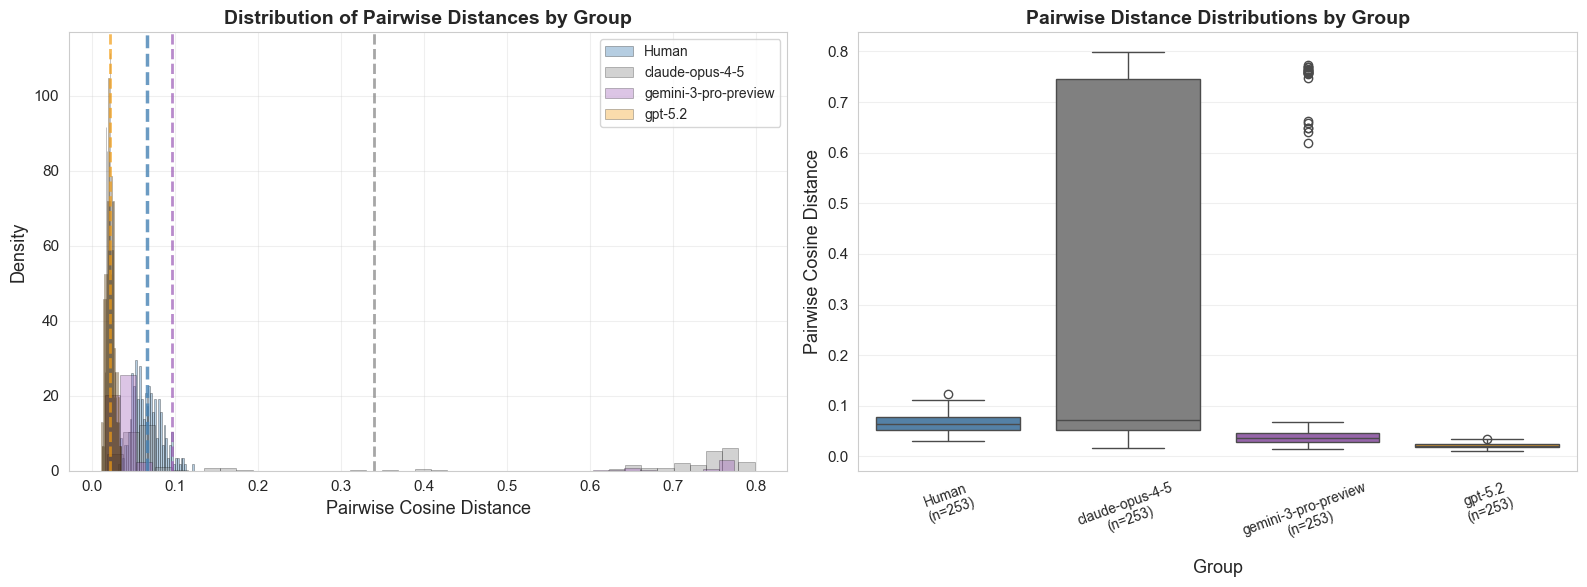

✓ Figure saved to: results/figures/pairwise_diversity_by_model.png


In [19]:
# Visualization: Distribution comparison for all groups
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define colors for each group
colors = {
    'Human': 'steelblue',
    'claude-opus-4-6': '#E74C3C',
    'gemini-3-pro-preview': '#9B59B6',
    'gpt-5.2': '#F39C12',
    'All AI': 'coral'
}

# LEFT PANEL: Overlapping histograms
axes[0].hist(human_pairwise, bins=40, alpha=0.4, label='Human', color=colors['Human'], density=True, edgecolor='black', linewidth=0.5)

for model in ai_models:
    if len(model_pairwise[model]) > 0:
        axes[0].hist(model_pairwise[model], bins=40, alpha=0.35, label=model, 
                    color=colors.get(model, 'gray'), density=True, edgecolor='black', linewidth=0.5)

# Add mean lines
axes[0].axvline(human_pairwise.mean(), color=colors['Human'], linestyle='--', linewidth=2.5, alpha=0.8)
for model in ai_models:
    if len(model_pairwise[model]) > 0:
        axes[0].axvline(model_pairwise[model].mean(), color=colors.get(model, 'gray'), 
                       linestyle='--', linewidth=2, alpha=0.7)

axes[0].set_xlabel('Pairwise Cosine Distance', fontsize=13)
axes[0].set_ylabel('Density', fontsize=13)
axes[0].set_title('Distribution of Pairwise Distances by Group', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# RIGHT PANEL: Box plot comparing all groups
box_data = []
for dist, label in [(human_pairwise, 'Human')] + [(model_pairwise[m], m) for m in ai_models if len(model_pairwise[m]) > 0]:
    for val in dist:
        box_data.append({'Distance': val, 'Group': label})

box_df = pd.DataFrame(box_data)

# Create box plot with custom colors
group_order = ['Human'] + [m for m in ai_models if len(model_pairwise[m]) > 0]
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.boxplot(data=box_df, x='Group', y='Distance', ax=axes[1], palette=palette_list, order=group_order)
axes[1].set_ylabel('Pairwise Cosine Distance', fontsize=13)
axes[1].set_xlabel('Group', fontsize=13)
axes[1].set_title('Pairwise Distance Distributions by Group', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(alpha=0.3, axis='y')

# Add sample sizes to x-axis labels
labels_with_n = [f"{g}\n(n={len(model_pairwise.get(g, human_pairwise if g=='Human' else []))})" for g in group_order]
axes[1].set_xticklabels(labels_with_n, fontsize=10)

plt.tight_layout()
plt.savefig('results/figures/pairwise_diversity_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/pairwise_diversity_by_model.png")


---

# Analysis 2.1.2: Centroid Dispersion Metric

Measure how scattered proposals are from their group center.

Compares:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**


In [22]:
def compute_centroid_distances(embeddings):
    """
    Compute distances from each proposal to its group centroid.
    """
    # Compute centroid (mean embedding)
    centroid = embeddings.mean(axis=0, keepdims=True)
    
    # Compute cosine distances to centroid
    distances = cosine_distances(embeddings, centroid).flatten()
    
    return distances, centroid

# Compute centroid distances for all groups
print("="*85)
print("COMPUTING CENTROID DISPERSION FOR ALL GROUPS")
print("="*85)

# Overall groups
ai_centroid_dists, ai_centroid = compute_centroid_distances(ai_embeddings)
human_centroid_dists, human_centroid = compute_centroid_distances(human_embeddings)

# Individual AI models
model_centroid_dists = {}
model_centroids = {}

for model in ai_models:
    if len(model_embeddings_dict[model]) > 0:
        dists, centroid = compute_centroid_distances(model_embeddings_dict[model])
        model_centroid_dists[model] = dists
        model_centroids[model] = centroid

# Print statistics table
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Std':<10} {'Variance':<10}")
print("-"*90)

# Human baseline
print(f"{'Human':<35} {len(human_embeddings):<8} {human_centroid_dists.mean():<10.4f} {np.median(human_centroid_dists):<10.4f} {human_centroid_dists.std():<10.4f} {human_centroid_dists.var():<10.4f}")

print()  # Blank line separator

# Individual AI models
for model in ai_models:
    if model in model_centroid_dists:
        dists = model_centroid_dists[model]
        n_proposals = len(model_embeddings_dict[model])
        print(f"{model:<35} {n_proposals:<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.std():<10.4f} {dists.var():<10.4f}")

print()  # Blank line separator

# All AI combined
print(f"{'All AI (combined)':<35} {len(ai_embeddings):<8} {ai_centroid_dists.mean():<10.4f} {np.median(ai_centroid_dists):<10.4f} {ai_centroid_dists.std():<10.4f} {ai_centroid_dists.var():<10.4f}")

print("="*90)
print("\n💡 INTERPRETATION:")
print("   - Higher variance = more dispersed proposals (higher diversity)")
print("   - Lower variance = proposals cluster tightly around center")
print("="*90)


COMPUTING CENTROID DISPERSION FOR ALL GROUPS

GROUP                               N        Mean       Median     Std        Variance  
------------------------------------------------------------------------------------------
Human                               23       0.0321     0.0294     0.0092     0.0001    

claude-opus-4-5                     23       0.1789     0.0736     0.1845     0.0340    
gemini-3-pro-preview                23       0.0473     0.0178     0.1348     0.0182    
gpt-5.2                             23       0.0104     0.0101     0.0023     0.0000    

All AI (combined)                   69       0.0894     0.0268     0.1836     0.0337    

💡 INTERPRETATION:
   - Higher variance = more dispersed proposals (higher diversity)
   - Lower variance = proposals cluster tightly around center


In [23]:
# Statistical tests - Compare each group to Human
print("\n" + "="*85)
print("STATISTICAL TESTS: Centroid Dispersion (All Groups vs Human)")
print("="*85)

# Store all results
centroid_comparison_results = []

# Compare All AI vs Human
print("\n" + "-"*85)
print("Comparison: All AI (combined) vs Human")
print("-"*85)

u_stat_cent, p_value_cent = mannwhitneyu(ai_centroid_dists, human_centroid_dists, alternative='two-sided')
delta_cent = cliffs_delta(ai_centroid_dists, human_centroid_dists)
delta_cent_interp = interpret_cliffs_delta(delta_cent)
p_value_perm_cent, obs_diff_cent, _ = permutation_test(ai_centroid_dists, human_centroid_dists)

print(f"\nMann-Whitney U Test:")
print(f"  U-statistic: {u_stat_cent:,.0f}, p-value: {p_value_cent:.4e}")
print(f"\nCliff's Delta:")
print(f"  δ = {delta_cent:.4f} ({delta_cent_interp} effect)")
if delta_cent > 0:
    print(f"  → All AI proposals are MORE dispersed from center")
else:
    print(f"  → Human proposals are MORE dispersed from center")
print(f"\nPermutation Test (10,000 permutations):")
print(f"  Observed difference: {obs_diff_cent:.4f}, p-value: {p_value_perm_cent:.4f}")

centroid_comparison_results.append({
    'group': 'All AI',
    'u_stat': u_stat_cent,
    'p_value_mw': p_value_cent,
    'delta': delta_cent,
    'delta_interp': delta_cent_interp,
    'p_value_perm': p_value_perm_cent
})

# Compare each individual AI model vs Human
for model in ai_models:
    if model in model_centroid_dists:
        print("\n" + "-"*85)
        print(f"Comparison: {model} vs Human")
        print("-"*85)
        
        u_stat_model, p_value_mw_model = mannwhitneyu(model_centroid_dists[model], human_centroid_dists, alternative='two-sided')
        delta_model = cliffs_delta(model_centroid_dists[model], human_centroid_dists)
        delta_interp_model = interpret_cliffs_delta(delta_model)
        p_value_perm_model, obs_diff_model, _ = permutation_test(model_centroid_dists[model], human_centroid_dists)
        
        print(f"\nMann-Whitney U Test:")
        print(f"  U-statistic: {u_stat_model:,.0f}, p-value: {p_value_mw_model:.4e}")
        print(f"\nCliff's Delta:")
        print(f"  δ = {delta_model:.4f} ({delta_interp_model} effect)")
        if delta_model > 0:
            print(f"  → {model} proposals are MORE dispersed from center")
        else:
            print(f"  → Human proposals are MORE dispersed from center")
        print(f"\nPermutation Test (10,000 permutations):")
        print(f"  Observed difference: {obs_diff_model:.4f}, p-value: {p_value_perm_model:.4f}")
        
        centroid_comparison_results.append({
            'group': model,
            'u_stat': u_stat_model,
            'p_value_mw': p_value_mw_model,
            'delta': delta_model,
            'delta_interp': delta_interp_model,
            'p_value_perm': p_value_perm_model
        })

# Summary table
print("\n" + "="*85)
print("SUMMARY: Effect Sizes (Cliff's Delta) - Centroid Dispersion")
print("="*85)
print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
print("-"*85)
for result in centroid_comparison_results:
    print(f"{result['group']:<30} {result['delta']:<12.4f} {result['delta_interp']:<20} {result['p_value_mw']:<15.4e}")
print("="*85)
print("\n💡 Positive δ = AI more dispersed; Negative δ = Human more dispersed")
print("="*85)



STATISTICAL TESTS: Centroid Dispersion (All Groups vs Human)

-------------------------------------------------------------------------------------
Comparison: All AI (combined) vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 657, p-value: 2.2008e-01

Cliff's Delta:
  δ = -0.1720 (small effect)
  → Human proposals are MORE dispersed from center

Permutation Test (10,000 permutations):
  Observed difference: 0.0573, p-value: 0.1747

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 527, p-value: 8.6168e-09

Cliff's Delta:
  δ = 0.9924 (large effect)
  → claude-opus-4-5 proposals are MORE dispersed from center

Permutation Test (10,000 permutations):
  Observed difference: 0.1467, p-value: 0.0000

--------------

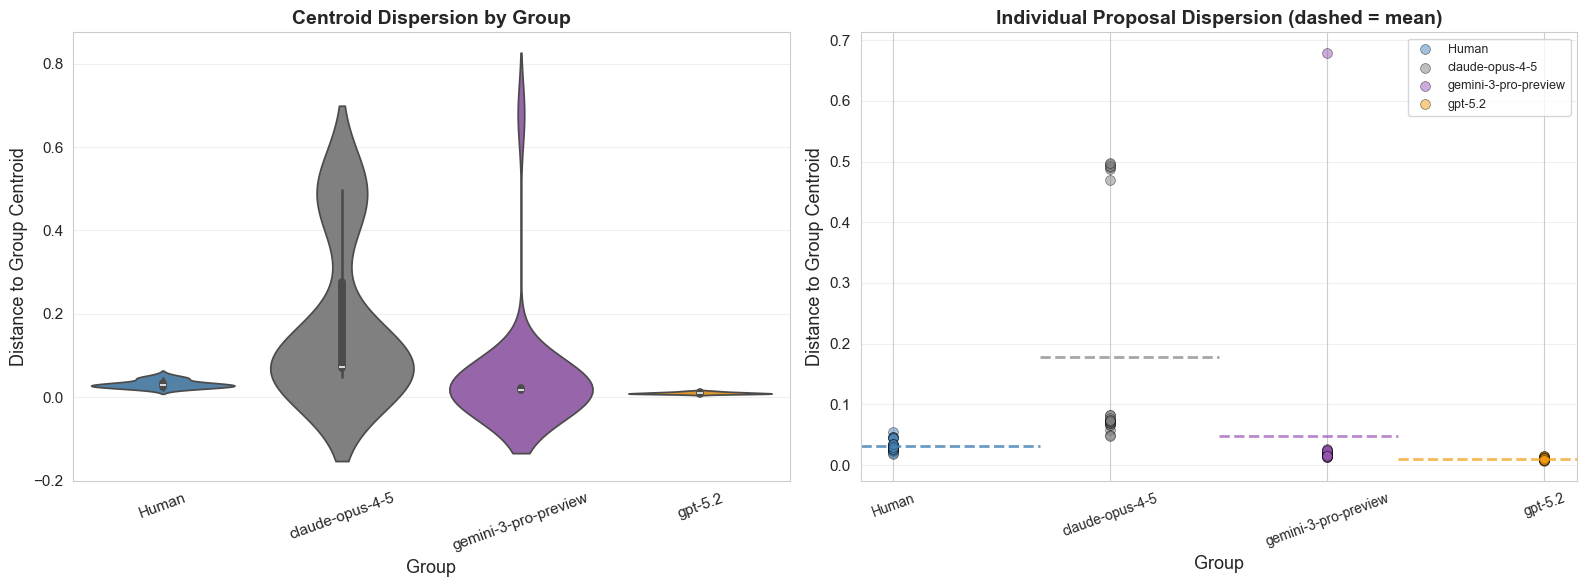

✓ Figure saved to: results/figures/centroid_dispersion_by_model.png


In [24]:
# Visualization: Centroid dispersion for all groups
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color scheme
colors = {
    'Human': 'steelblue',
    'claude-opus-4-6': '#E74C3C',
    'gemini-3-pro-preview': '#9B59B6',
    'gpt-5.2': '#F39C12',
    'All AI': 'coral'
}

# LEFT PANEL: Violin plots
violin_data = []
for dist, label in [(human_centroid_dists, 'Human')] + [(model_centroid_dists[m], m) for m in ai_models if m in model_centroid_dists]:
    for val in dist:
        violin_data.append({'Distance to Centroid': val, 'Group': label})

violin_df = pd.DataFrame(violin_data)
group_order = ['Human'] + [m for m in ai_models if m in model_centroid_dists]
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.violinplot(data=violin_df, x='Group', y='Distance to Centroid', ax=axes[0], palette=palette_list, order=group_order)
axes[0].set_ylabel('Distance to Group Centroid', fontsize=13)
axes[0].set_xlabel('Group', fontsize=13)
axes[0].set_title('Centroid Dispersion by Group', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

# RIGHT PANEL: Scatter plot showing individual proposals
offset = 0
x_positions = {}

# Human
x_positions['Human'] = 0
axes[1].scatter([0]*len(human_centroid_dists), human_centroid_dists, 
               alpha=0.5, label='Human', color=colors['Human'], s=50, edgecolors='black', linewidth=0.5)
axes[1].axhline(human_centroid_dists.mean(), xmin=0/len(group_order), xmax=1/len(group_order), 
               color=colors['Human'], linestyle='--', linewidth=2, alpha=0.8)

offset = 1
# Individual AI models
for i, model in enumerate([m for m in ai_models if m in model_centroid_dists]):
    x_positions[model] = offset
    axes[1].scatter([offset]*len(model_centroid_dists[model]), model_centroid_dists[model], 
                   alpha=0.5, label=model, color=colors.get(model, 'gray'), s=50, edgecolors='black', linewidth=0.5)
    axes[1].axhline(model_centroid_dists[model].mean(), 
                   xmin=offset/len(group_order), xmax=(offset+1)/len(group_order),
                   color=colors.get(model, 'gray'), linestyle='--', linewidth=2, alpha=0.7)
    offset += 1

axes[1].set_xticks(range(len(group_order)))
axes[1].set_xticklabels(group_order, rotation=20, fontsize=10)
axes[1].set_ylabel('Distance to Group Centroid', fontsize=13)
axes[1].set_xlabel('Group', fontsize=13)
axes[1].set_title('Individual Proposal Dispersion (dashed = mean)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/figures/centroid_dispersion_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/centroid_dispersion_by_model.png")


---

# Analysis 2.1.3: Nearest-Neighbor Outlier Detection

Identify "lone wolf" ideas far from everything else.

Compares:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**


In [25]:
# Combine all embeddings for global nearest-neighbor analysis
all_embeddings = np.vstack([human_embeddings, ai_embeddings])
n_human = len(human_embeddings)
n_ai = len(ai_embeddings)

# Compute full distance matrix
print("="*85)
print("COMPUTING NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS")
print("="*85)

all_distances = cosine_distances(all_embeddings)

# For each proposal, find nearest neighbor distance
# (set diagonal to infinity to exclude self)
np.fill_diagonal(all_distances, np.inf)
nn_distances = all_distances.min(axis=1)

# Split by group
human_nn_dists = nn_distances[:n_human]
ai_nn_dists = nn_distances[n_human:]

# Extract per-model NN distances
model_nn_dists = {}
cumulative_offset = n_human  # Start after human proposals

for model in ai_models:
    n_model = len(model_embeddings_dict[model])
    if n_model > 0:
        model_nn_dists[model] = nn_distances[cumulative_offset:cumulative_offset + n_model]
        cumulative_offset += n_model

# Print statistics table
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
print("-"*85)

# Human baseline
print(f"{'Human':<35} {len(human_nn_dists):<8} {human_nn_dists.mean():<10.4f} {np.median(human_nn_dists):<10.4f} {human_nn_dists.min():<10.4f} {human_nn_dists.max():<10.4f}")

print()  # Blank line separator

# Individual AI models
for model in ai_models:
    if model in model_nn_dists:
        dists = model_nn_dists[model]
        print(f"{model:<35} {len(dists):<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.min():<10.4f} {dists.max():<10.4f}")

print()  # Blank line separator

# All AI combined
print(f"{'All AI (combined)':<35} {len(ai_nn_dists):<8} {ai_nn_dists.mean():<10.4f} {np.median(ai_nn_dists):<10.4f} {ai_nn_dists.min():<10.4f} {ai_nn_dists.max():<10.4f}")

print("="*85)
print("\n💡 INTERPRETATION:")
print("   - Higher mean NN distance = more isolated proposals (outliers)")
print("   - Lower mean NN distance = proposals cluster together")
print("="*85)


COMPUTING NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.0372     0.0349     0.0236     0.0646    

claude-opus-4-5                     23       0.0139     0.0138     0.0111     0.0191    
gemini-3-pro-preview                23       0.0313     0.0230     0.0148     0.2322    
gpt-5.2                             23       0.0563     0.0392     0.0144     0.3112    

All AI (combined)                   69       0.0339     0.0191     0.0111     0.3112    

💡 INTERPRETATION:
   - Higher mean NN distance = more isolated proposals (outliers)
   - Lower mean NN distance = proposals cluster together


In [26]:
# Identify outliers (top 10% of NN distances)
threshold = np.percentile(nn_distances, 90)
outliers = nn_distances > threshold

human_outliers = outliers[:n_human].sum()
ai_outliers = outliers[n_human:].sum()

# Per-model outlier detection
model_outliers = {}
cumulative_offset = n_human

for model in ai_models:
    n_model = len(model_embeddings_dict[model])
    if n_model > 0:
        model_outliers[model] = outliers[cumulative_offset:cumulative_offset + n_model].sum()
        cumulative_offset += n_model

print("\n" + "="*85)
print("OUTLIER DETECTION (Top 10% Nearest-Neighbor Distance)")
print("="*85)
print(f"Threshold distance: {threshold:.4f}")
print()

print(f"{'GROUP':<35} {'Outliers':<15} {'Total':<10} {'Percentage':<15}")
print("-"*85)

# Human
print(f"{'Human':<35} {human_outliers:<15} {n_human:<10} {human_outliers/n_human*100:<15.1f}%")

print()  # Blank line

# Per-model outliers
for model in ai_models:
    if model in model_outliers:
        n_model = len(model_embeddings_dict[model])
        print(f"{model:<35} {model_outliers[model]:<15} {n_model:<10} {model_outliers[model]/n_model*100:<15.1f}%")

print()  # Blank line

# All AI
print(f"{'All AI (combined)':<35} {ai_outliers:<15} {n_ai:<10} {ai_outliers/n_ai*100:<15.1f}%")

print("="*85)



OUTLIER DETECTION (Top 10% Nearest-Neighbor Distance)
Threshold distance: 0.0488

GROUP                               Outliers        Total      Percentage     
-------------------------------------------------------------------------------------
Human                               3               23         13.0           %

claude-opus-4-5                     0               23         0.0            %
gemini-3-pro-preview                1               23         4.3            %
gpt-5.2                             6               23         26.1           %

All AI (combined)                   7               69         10.1           %


In [27]:
# Find nearest neighbor's group for each proposal
nn_indices = all_distances.argmin(axis=1)

# Determine if NN is from same or different group
human_nn_same_group = (nn_indices[:n_human] < n_human).sum()
human_nn_diff_group = n_human - human_nn_same_group

ai_nn_same_group = (nn_indices[n_human:] >= n_human).sum()
ai_nn_diff_group = n_ai - ai_nn_same_group

# Per-model nearest neighbor group analysis
model_nn_analysis = {}
cumulative_offset = n_human

for model in ai_models:
    n_model = len(model_embeddings_dict[model])
    if n_model > 0:
        model_nn_indices = nn_indices[cumulative_offset:cumulative_offset + n_model]
        
        # NN from human
        nn_from_human = (model_nn_indices < n_human).sum()
        # NN from same AI model (need to check range)
        nn_from_same_model = ((model_nn_indices >= cumulative_offset) & 
                              (model_nn_indices < cumulative_offset + n_model)).sum()
        # NN from other AI models
        nn_from_other_ai = n_model - nn_from_human - nn_from_same_model
        
        model_nn_analysis[model] = {
            'from_human': nn_from_human,
            'from_same_model': nn_from_same_model,
            'from_other_ai': nn_from_other_ai,
            'total': n_model
        }
        
        cumulative_offset += n_model

print("\n" + "="*85)
print("NEAREST NEIGHBOR GROUP ANALYSIS")
print("="*85)

print(f"\n{'Human proposals:':<50}")
print(f"  NN from same group (human): {human_nn_same_group} ({human_nn_same_group/n_human*100:.1f}%)")
print(f"  NN from different group (AI): {human_nn_diff_group} ({human_nn_diff_group/n_human*100:.1f}%)")

print(f"\n{'All AI proposals (combined):':<50}")
print(f"  NN from same group (AI): {ai_nn_same_group} ({ai_nn_same_group/n_ai*100:.1f}%)")
print(f"  NN from different group (human): {ai_nn_diff_group} ({ai_nn_diff_group/n_ai*100:.1f}%)")

print("\n" + "-"*85)
print("Per-Model NN Group Breakdown:")
print("-"*85)

for model in ai_models:
    if model in model_nn_analysis:
        data = model_nn_analysis[model]
        print(f"\n{model}:")
        print(f"  NN from Human: {data['from_human']} ({data['from_human']/data['total']*100:.1f}%)")
        print(f"  NN from same model: {data['from_same_model']} ({data['from_same_model']/data['total']*100:.1f}%)")
        print(f"  NN from other AI models: {data['from_other_ai']} ({data['from_other_ai']/data['total']*100:.1f}%)")

print("\n" + "="*85)
print("\n💡 INTERPRETATION:")
print("   - High 'NN from same model' = model produces similar proposals")
print("   - High 'NN from Human' = model proposals resemble human work")
print("="*85)



NEAREST NEIGHBOR GROUP ANALYSIS

Human proposals:                                  
  NN from same group (human): 10 (43.5%)
  NN from different group (AI): 13 (56.5%)

All AI proposals (combined):                      
  NN from same group (AI): 69 (100.0%)
  NN from different group (human): 0 (0.0%)

-------------------------------------------------------------------------------------
Per-Model NN Group Breakdown:
-------------------------------------------------------------------------------------

claude-opus-4-5:
  NN from Human: 0 (0.0%)
  NN from same model: 22 (95.7%)
  NN from other AI models: 1 (4.3%)

gemini-3-pro-preview:
  NN from Human: 0 (0.0%)
  NN from same model: 16 (69.6%)
  NN from other AI models: 7 (30.4%)

gpt-5.2:
  NN from Human: 0 (0.0%)
  NN from same model: 16 (69.6%)
  NN from other AI models: 7 (30.4%)


💡 INTERPRETATION:
   - High 'NN from same model' = model produces similar proposals
   - High 'NN from Human' = model proposals resemble human work


In [28]:
# Statistical tests - Compare each group to Human
print("\n" + "="*85)
print("STATISTICAL TESTS: Nearest-Neighbor Distances (All Groups vs Human)")
print("="*85)

# Store all results
nn_comparison_results = []

# Compare All AI vs Human
print("\n" + "-"*85)
print("Comparison: All AI (combined) vs Human")
print("-"*85)

u_stat_nn, p_value_nn = mannwhitneyu(ai_nn_dists, human_nn_dists, alternative='two-sided')
delta_nn = cliffs_delta(ai_nn_dists, human_nn_dists)
delta_nn_interp = interpret_cliffs_delta(delta_nn)
p_value_perm_nn, obs_diff_nn, _ = permutation_test(ai_nn_dists, human_nn_dists)

print(f"\nMann-Whitney U Test:")
print(f"  U-statistic: {u_stat_nn:,.0f}, p-value: {p_value_nn:.4e}")
print(f"\nCliff's Delta:")
print(f"  δ = {delta_nn:.4f} ({delta_nn_interp} effect)")
if delta_nn > 0:
    print(f"  → All AI proposals have MORE unique/outlier ideas")
else:
    print(f"  → Human proposals have MORE unique/outlier ideas")
print(f"\nPermutation Test (10,000 permutations):")
print(f"  Observed difference: {obs_diff_nn:.4f}, p-value: {p_value_perm_nn:.4f}")

nn_comparison_results.append({
    'group': 'All AI',
    'u_stat': u_stat_nn,
    'p_value_mw': p_value_nn,
    'delta': delta_nn,
    'delta_interp': delta_nn_interp,
    'p_value_perm': p_value_perm_nn
})

# Compare each individual AI model vs Human
for model in ai_models:
    if model in model_nn_dists:
        print("\n" + "-"*85)
        print(f"Comparison: {model} vs Human")
        print("-"*85)
        
        u_stat_model, p_value_mw_model = mannwhitneyu(model_nn_dists[model], human_nn_dists, alternative='two-sided')
        delta_model = cliffs_delta(model_nn_dists[model], human_nn_dists)
        delta_interp_model = interpret_cliffs_delta(delta_model)
        p_value_perm_model, obs_diff_model, _ = permutation_test(model_nn_dists[model], human_nn_dists)
        
        print(f"\nMann-Whitney U Test:")
        print(f"  U-statistic: {u_stat_model:,.0f}, p-value: {p_value_mw_model:.4e}")
        print(f"\nCliff's Delta:")
        print(f"  δ = {delta_model:.4f} ({delta_interp_model} effect)")
        if delta_model > 0:
            print(f"  → {model} proposals have MORE unique/outlier ideas")
        else:
            print(f"  → Human proposals have MORE unique/outlier ideas")
        print(f"\nPermutation Test (10,000 permutations):")
        print(f"  Observed difference: {obs_diff_model:.4f}, p-value: {p_value_perm_model:.4f}")
        
        nn_comparison_results.append({
            'group': model,
            'u_stat': u_stat_model,
            'p_value_mw': p_value_mw_model,
            'delta': delta_model,
            'delta_interp': delta_interp_model,
            'p_value_perm': p_value_perm_model
        })

# Summary table
print("\n" + "="*85)
print("SUMMARY: Effect Sizes (Cliff's Delta) - Nearest-Neighbor Distances")
print("="*85)
print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
print("-"*85)
for result in nn_comparison_results:
    print(f"{result['group']:<30} {result['delta']:<12.4f} {result['delta_interp']:<20} {result['p_value_mw']:<15.4e}")
print("="*85)
print("\n💡 Positive δ = AI more outlier-prone; Negative δ = Human more outlier-prone")
print("="*85)



STATISTICAL TESTS: Nearest-Neighbor Distances (All Groups vs Human)

-------------------------------------------------------------------------------------
Comparison: All AI (combined) vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 344, p-value: 5.1476e-05

Cliff's Delta:
  δ = -0.5665 (large effect)
  → Human proposals have MORE unique/outlier ideas

Permutation Test (10,000 permutations):
  Observed difference: -0.0033, p-value: 0.8019

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 0, p-value: 6.5945e-09

Cliff's Delta:
  δ = -1.0000 (large effect)
  → Human proposals have MORE unique/outlier ideas

Permutation Test (10,000 permutations):
  Observed difference: -0.0233, p-value: 0.0000

----------------

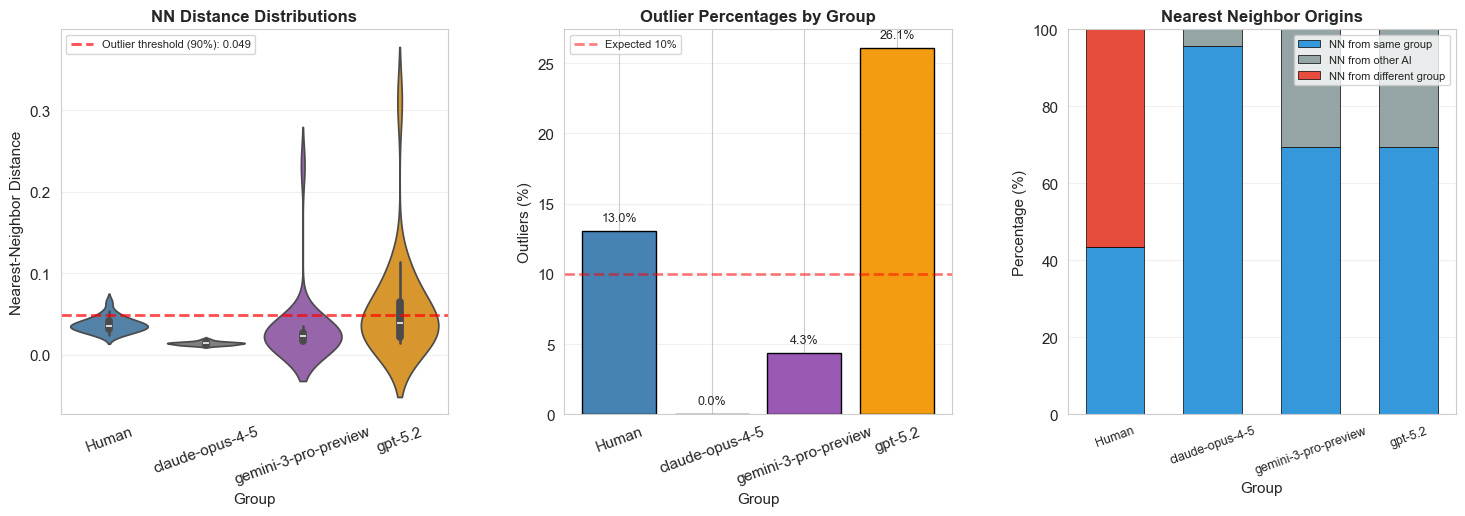

✓ Figure saved to: results/figures/nearest_neighbor_by_model.png


In [29]:
# Visualization: Nearest-neighbor analysis by group
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# Color scheme
colors = {
    'Human': 'steelblue',
    'claude-opus-4-6': '#E74C3C',
    'gemini-3-pro-preview': '#9B59B6',
    'gpt-5.2': '#F39C12',
    'All AI': 'coral'
}

# 1. NN distance distributions by group
ax1 = fig.add_subplot(gs[0, 0])
nn_data = []
for dist, label in [(human_nn_dists, 'Human')] + [(model_nn_dists[m], m) for m in ai_models if m in model_nn_dists]:
    for val in dist:
        nn_data.append({'NN Distance': val, 'Group': label})

nn_df = pd.DataFrame(nn_data)
group_order = ['Human'] + [m for m in ai_models if m in model_nn_dists]
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.violinplot(data=nn_df, x='Group', y='NN Distance', ax=ax1, palette=palette_list, order=group_order)
ax1.axhline(threshold, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Outlier threshold (90%): {threshold:.3f}')
ax1.set_ylabel('Nearest-Neighbor Distance', fontsize=11)
ax1.set_xlabel('Group', fontsize=11)
ax1.set_title('NN Distance Distributions', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3, axis='y')

# 2. Outlier counts by group
ax2 = fig.add_subplot(gs[0, 1])
outlier_data = []
outlier_data.append({'Group': 'Human', 'Outliers': human_outliers, 'Total': n_human, 'Percentage': human_outliers/n_human*100})

for model in ai_models:
    if model in model_outliers:
        n_model = len(model_embeddings_dict[model])
        outlier_data.append({
            'Group': model,
            'Outliers': model_outliers[model],
            'Total': n_model,
            'Percentage': model_outliers[model]/n_model*100
        })

outlier_df = pd.DataFrame(outlier_data)
bars = ax2.bar(outlier_df['Group'], outlier_df['Percentage'], color=[colors.get(g, 'gray') for g in outlier_df['Group']], 
               edgecolor='black', linewidth=1)
ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected 10%')
ax2.set_ylabel('Outliers (%)', fontsize=11)
ax2.set_xlabel('Group', fontsize=11)
ax2.set_title('Outlier Percentages by Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=20)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (bar, pct) in enumerate(zip(bars, outlier_df['Percentage'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# 3. NN Group Analysis - Stacked bar chart
ax3 = fig.add_subplot(gs[0, 2])

# Prepare data for stacked bars
groups = ['Human'] + [m for m in ai_models if m in model_nn_analysis]
nn_from_human_pcts = [human_nn_diff_group/n_human*100]  # For human, this is NN from AI
nn_from_same_pcts = [human_nn_same_group/n_human*100]  # For human, this is NN from human
nn_from_other_ai_pcts = [0]  # Human doesn't have this category

for model in [m for m in ai_models if m in model_nn_analysis]:
    data = model_nn_analysis[model]
    nn_from_human_pcts.append(data['from_human']/data['total']*100)
    nn_from_same_pcts.append(data['from_same_model']/data['total']*100)
    nn_from_other_ai_pcts.append(data['from_other_ai']/data['total']*100)

x_pos = np.arange(len(groups))
width = 0.6

# Adjust labels for Human
p1 = ax3.bar(x_pos, nn_from_same_pcts, width, label='NN from same group', color='#3498db', edgecolor='black', linewidth=0.5)
p2 = ax3.bar(x_pos, nn_from_other_ai_pcts, width, bottom=nn_from_same_pcts, label='NN from other AI', color='#95a5a6', edgecolor='black', linewidth=0.5)
bottom = np.array(nn_from_same_pcts) + np.array(nn_from_other_ai_pcts)
p3 = ax3.bar(x_pos, nn_from_human_pcts, width, bottom=bottom, label='NN from different group', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax3.set_ylabel('Percentage (%)', fontsize=11)
ax3.set_xlabel('Group', fontsize=11)
ax3.set_title('Nearest Neighbor Origins', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(groups, rotation=20, fontsize=9)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(alpha=0.3, axis='y')
ax3.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('results/figures/nearest_neighbor_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/nearest_neighbor_by_model.png")


### Embedding Space Visualization

Visualize all proposals in 2D space using UMAP dimensionality reduction to see:
- **Clustering patterns**: How proposals group together
- **Outliers**: Unique proposals far from others (highlighted in magenta)
- **Group separation**: How Human vs AI proposals distribute in semantic space
- **Model characteristics**: Whether different AI models produce distinctly clustered proposals

**Color coding**: Human proposals in bright red for easy identification, AI models in muted colors.


VISUALIZING PROPOSALS IN 2D EMBEDDING SPACE

Reducing embeddings to 2D using UMAP...
✓ UMAP completed: 92 proposals reduced to 2D


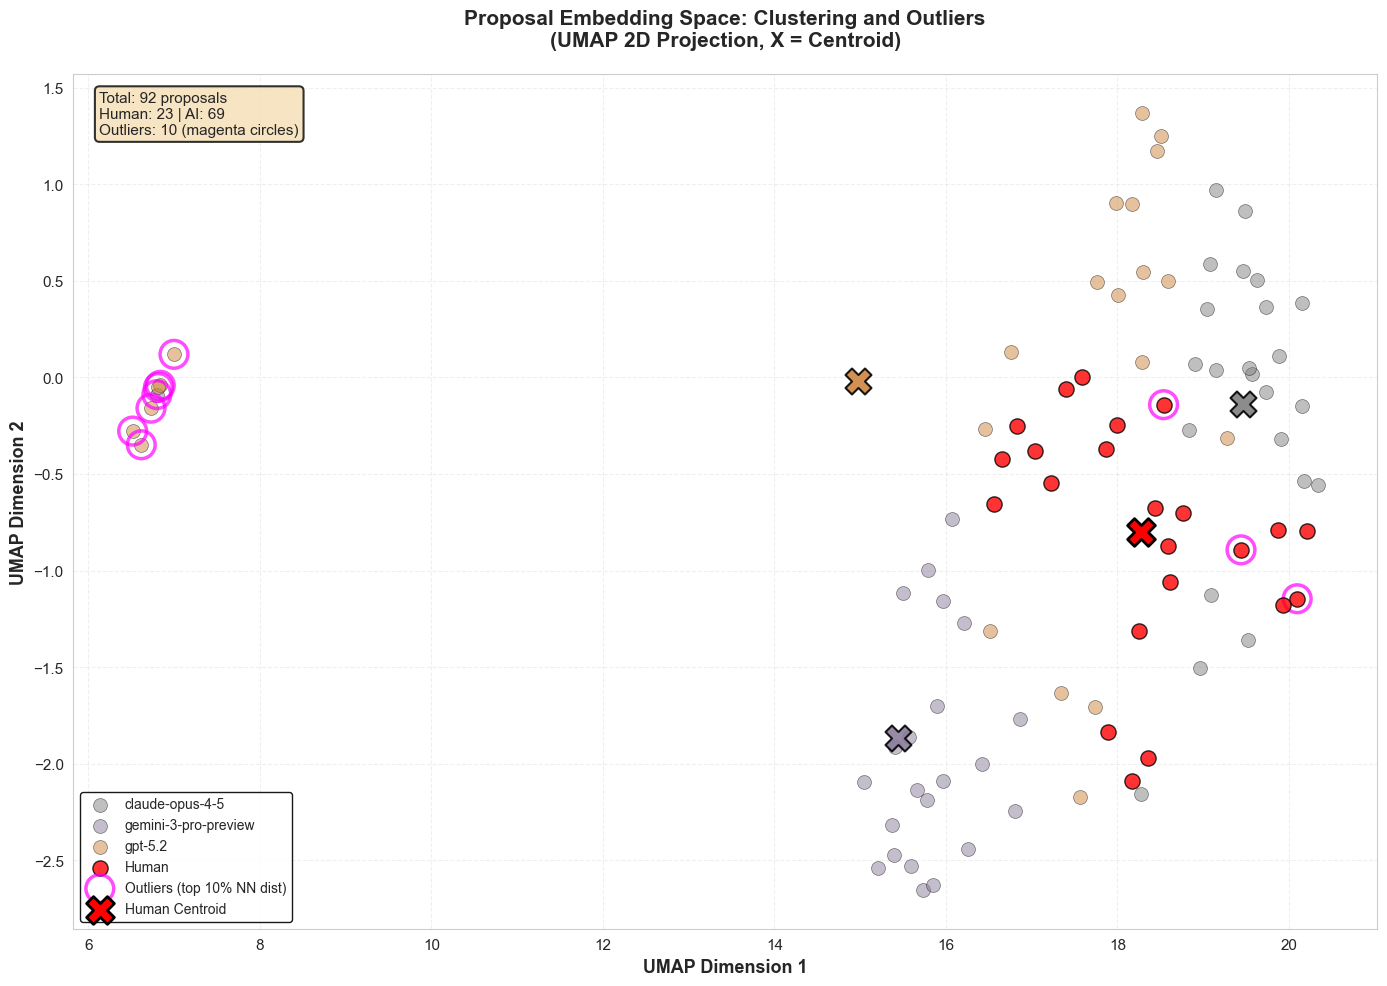


✓ Figure saved to: results/figures/embedding_space_2d.png

💡 INTERPRETATION:
   - Clusters = similar proposals
   - Outliers (magenta circles) = unique/distant proposals
   - X markers = group centroids
   - Distance between groups shows overall similarity


In [33]:
# Visualization: 2D Embedding Space with UMAP
# Install umap-learn if not already installed
try:
    import umap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'umap-learn'])
    import umap

print("\n" + "="*85)
print("VISUALIZING PROPOSALS IN 2D EMBEDDING SPACE")
print("="*85)

# Apply UMAP dimensionality reduction
print("\nReducing embeddings to 2D using UMAP...")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

# Combine all embeddings for UMAP
all_embeddings_umap = np.vstack([human_embeddings, ai_embeddings])
embeddings_2d = reducer.fit_transform(all_embeddings_umap)

# Split back into groups
human_2d = embeddings_2d[:n_human]
ai_2d = embeddings_2d[n_human:]

# Extract per-model 2D embeddings
model_2d = {}
cumulative_offset = 0
for model in ai_models:
    n_model = len(model_embeddings_dict[model])
    if n_model > 0:
        model_2d[model] = ai_2d[cumulative_offset:cumulative_offset + n_model]
        cumulative_offset += n_model

print(f"✓ UMAP completed: {len(embeddings_2d)} proposals reduced to 2D")

# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Color scheme - bright red for human, muted colors for AI
colors = {
    'Human': '#FF0000',  # Bright red
    'claude-opus-4-6': '#B8860B',  # Muted gold
    'gemini-3-pro-preview': '#8B7D9B',  # Muted purple
    'gpt-5.2': '#CD853F',  # Muted orange/tan
}

# Plot AI models first (so human is on top)
for model in ai_models:
    if model in model_2d:
        ax.scatter(model_2d[model][:, 0], model_2d[model][:, 1],
                  c=colors.get(model, '#808080'),
                  label=model,
                  s=100,
                  alpha=0.5,
                  edgecolors='black',
                  linewidth=0.5)

# Plot human proposals on top (bright red)
ax.scatter(human_2d[:, 0], human_2d[:, 1],
          c=colors['Human'],
          label='Human',
          s=120,
          alpha=0.8,
          edgecolors='black',
          linewidth=1.0,
          marker='o',
          zorder=10)  # Ensure human points are on top

# Highlight outliers with a circle
outlier_indices = np.where(outliers)[0]
outlier_coords = embeddings_2d[outlier_indices]

ax.scatter(outlier_coords[:, 0], outlier_coords[:, 1],
          s=400,
          facecolors='none',
          edgecolors='magenta',
          linewidth=2.5,
          alpha=0.7,
          label=f'Outliers (top 10% NN dist)',
          zorder=5)

# Calculate and plot centroids for each group
human_centroid_2d = human_2d.mean(axis=0)
ax.scatter(human_centroid_2d[0], human_centroid_2d[1],
          c=colors['Human'],
          s=400,
          marker='X',
          edgecolors='black',
          linewidth=2,
          alpha=1.0,
          zorder=15,
          label='Human Centroid')

for model in ai_models:
    if model in model_2d:
        model_centroid_2d = model_2d[model].mean(axis=0)
        ax.scatter(model_centroid_2d[0], model_centroid_2d[1],
                  c=colors.get(model, '#808080'),
                  s=350,
                  marker='X',
                  edgecolors='black',
                  linewidth=1.5,
                  alpha=0.9,
                  zorder=12)

# Labels and formatting
ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
ax.set_title('Proposal Embedding Space: Clustering and Outliers\n(UMAP 2D Projection, X = Centroid)',
            fontsize=15, fontweight='bold', pad=20)

# Legend
ax.legend(loc='best', fontsize=10, framealpha=0.9, edgecolor='black')

# Grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add text annotation with key insights
textstr = f'Total: {len(embeddings_2d)} proposals\n'
textstr += f'Human: {n_human} | AI: {n_ai}\n'
textstr += f'Outliers: {len(outlier_indices)} (magenta circles)'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
       verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('results/figures/embedding_space_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/embedding_space_2d.png")
print("\n💡 INTERPRETATION:")
print("   - Clusters = similar proposals")
print("   - Outliers (magenta circles) = unique/distant proposals")
print("   - X markers = group centroids")
print("   - Distance between groups shows overall similarity")
print("="*85)



ALTERNATIVE VIEW: t-SNE Projection

Reducing embeddings to 2D using t-SNE...
(This may take a minute...)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


✓ t-SNE completed


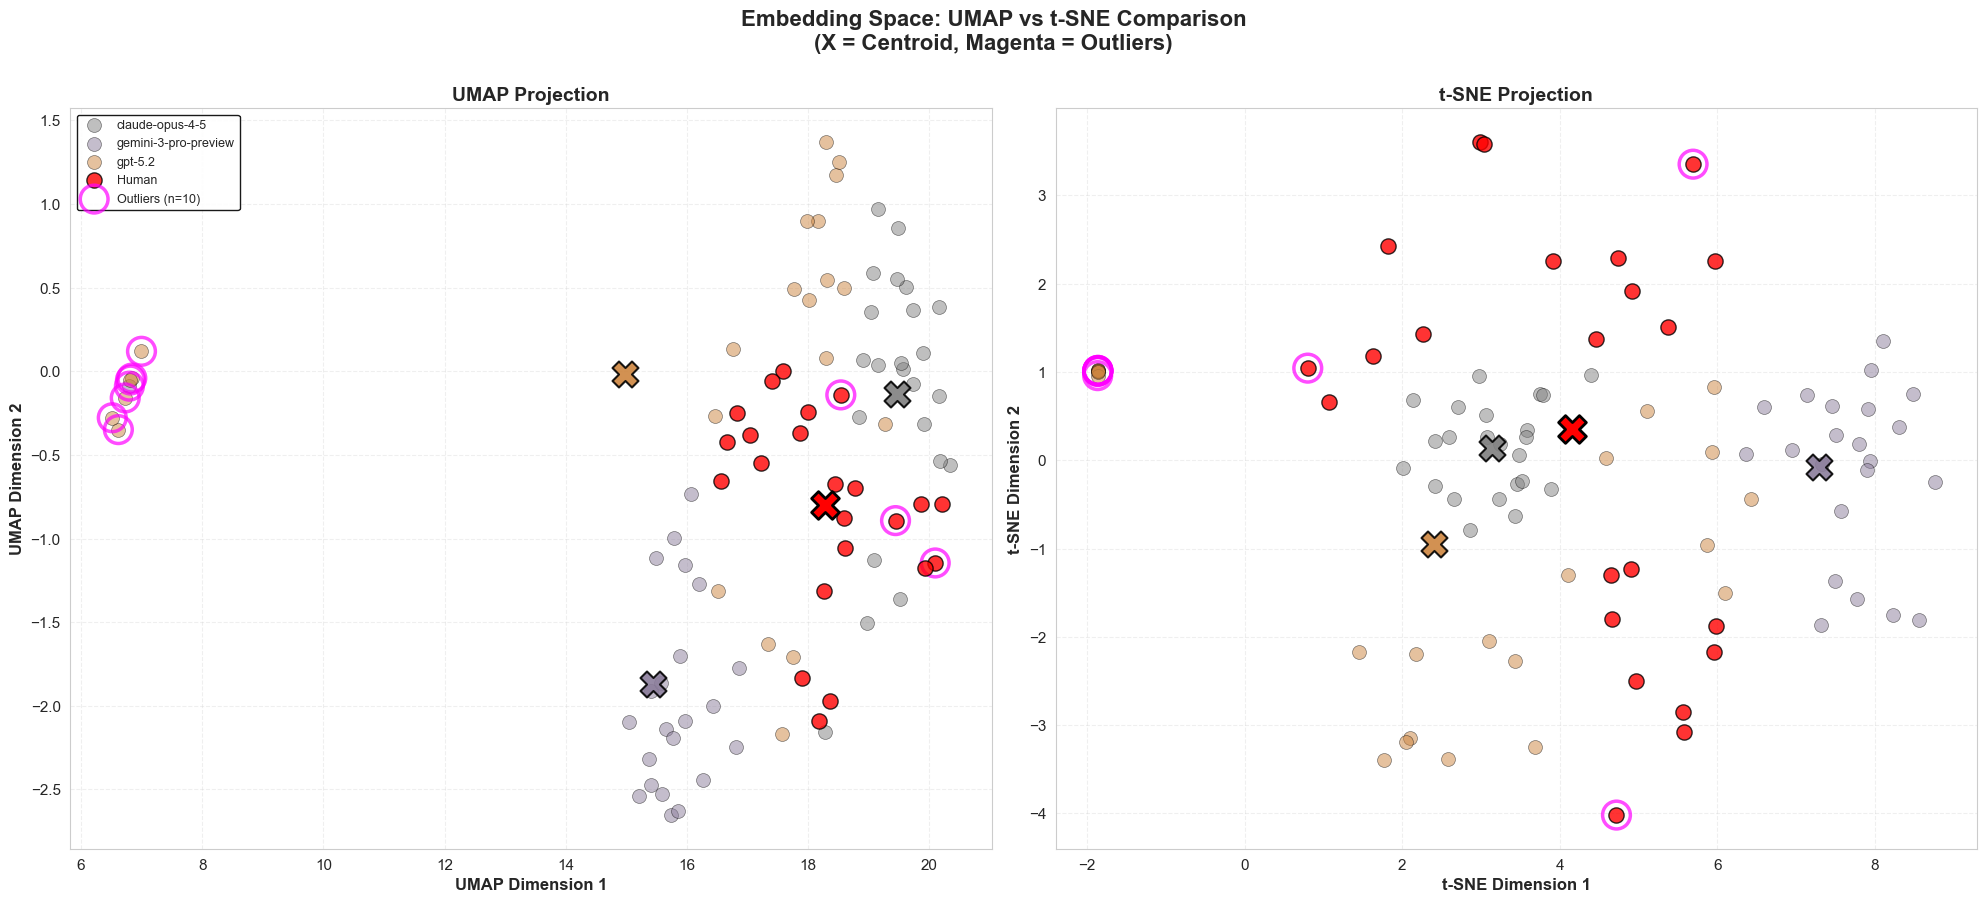


✓ Figure saved to: results/figures/embedding_space_comparison.png

💡 COMPARISON:
   - UMAP: Better preserves global structure, shows overall relationships
   - t-SNE: Emphasizes local neighborhoods, may show tighter clusters
   - Both methods reveal similar patterns if results are consistent


In [34]:
# Alternative visualization: t-SNE (complementary to UMAP)
from sklearn.manifold import TSNE

print("\n" + "="*85)
print("ALTERNATIVE VIEW: t-SNE Projection")
print("="*85)

# Apply t-SNE dimensionality reduction
print("\nReducing embeddings to 2D using t-SNE...")
print("(This may take a minute...)")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    metric='cosine',
    random_state=42,
    n_iter=1000,
    verbose=0
)

embeddings_2d_tsne = tsne.fit_transform(all_embeddings_umap)

# Split back into groups
human_2d_tsne = embeddings_2d_tsne[:n_human]
ai_2d_tsne = embeddings_2d_tsne[n_human:]

# Extract per-model 2D embeddings
model_2d_tsne = {}
cumulative_offset = 0
for model in ai_models:
    n_model = len(model_embeddings_dict[model])
    if n_model > 0:
        model_2d_tsne[model] = ai_2d_tsne[cumulative_offset:cumulative_offset + n_model]
        cumulative_offset += n_model

print(f"✓ t-SNE completed")

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Plot both UMAP and t-SNE
for idx, (coords_dict, method_name, ax) in enumerate([
    ({'Human': human_2d, **{m: model_2d[m] for m in ai_models if m in model_2d}}, 'UMAP', axes[0]),
    ({'Human': human_2d_tsne, **{m: model_2d_tsne[m] for m in ai_models if m in model_2d_tsne}}, 't-SNE', axes[1])
]):
    
    # Plot AI models first
    for model in ai_models:
        if model in coords_dict and model != 'Human':
            ax.scatter(coords_dict[model][:, 0], coords_dict[model][:, 1],
                      c=colors.get(model, '#808080'),
                      label=model,
                      s=100,
                      alpha=0.5,
                      edgecolors='black',
                      linewidth=0.5)
    
    # Plot human proposals on top
    ax.scatter(coords_dict['Human'][:, 0], coords_dict['Human'][:, 1],
              c=colors['Human'],
              label='Human',
              s=120,
              alpha=0.8,
              edgecolors='black',
              linewidth=1.0,
              marker='o',
              zorder=10)
    
    # Highlight outliers
    if idx == 0:
        outlier_coords_plot = embeddings_2d[outlier_indices]
    else:
        outlier_coords_plot = embeddings_2d_tsne[outlier_indices]
    
    ax.scatter(outlier_coords_plot[:, 0], outlier_coords_plot[:, 1],
              s=400,
              facecolors='none',
              edgecolors='magenta',
              linewidth=2.5,
              alpha=0.7,
              label=f'Outliers (n={len(outlier_indices)})',
              zorder=5)
    
    # Plot centroids
    if idx == 0:
        human_centroid_plot = human_2d.mean(axis=0)
        model_centroids_plot = {m: model_2d[m].mean(axis=0) for m in ai_models if m in model_2d}
    else:
        human_centroid_plot = human_2d_tsne.mean(axis=0)
        model_centroids_plot = {m: model_2d_tsne[m].mean(axis=0) for m in ai_models if m in model_2d_tsne}
    
    ax.scatter(human_centroid_plot[0], human_centroid_plot[1],
              c=colors['Human'],
              s=400,
              marker='X',
              edgecolors='black',
              linewidth=2,
              alpha=1.0,
              zorder=15)
    
    for model, centroid in model_centroids_plot.items():
        ax.scatter(centroid[0], centroid[1],
                  c=colors.get(model, '#808080'),
                  s=350,
                  marker='X',
                  edgecolors='black',
                  linewidth=1.5,
                  alpha=0.9,
                  zorder=12)
    
    # Formatting
    ax.set_xlabel(f'{method_name} Dimension 1', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{method_name} Dimension 2', fontsize=12, fontweight='bold')
    ax.set_title(f'{method_name} Projection', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if idx == 0:
        ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')

plt.suptitle('Embedding Space: UMAP vs t-SNE Comparison\n(X = Centroid, Magenta = Outliers)',
            fontsize=16, fontweight='bold', y=1.00)

plt.tight_layout()
plt.savefig('results/figures/embedding_space_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/embedding_space_comparison.png")
print("\n💡 COMPARISON:")
print("   - UMAP: Better preserves global structure, shows overall relationships")
print("   - t-SNE: Emphasizes local neighborhoods, may show tighter clusters")
print("   - Both methods reveal similar patterns if results are consistent")
print("="*85)


---

# Summary Report

In [35]:
# Create comprehensive summary with per-model analysis
summary = {
    'analysis_date': datetime.now().isoformat(),
    'sample_sizes': {
        'human_proposals': n_human,
        'ai_proposals': n_ai,
        'ai_by_model': ai_df['model'].value_counts().to_dict()
    },
    'pairwise_diversity': {
        'human': {
            'mean': float(human_pairwise.mean()),
            'median': float(np.median(human_pairwise)),
            'std': float(human_pairwise.std())
        },
        'ai_combined': {
            'mean': float(ai_pairwise.mean()),
            'median': float(np.median(ai_pairwise)),
            'std': float(ai_pairwise.std())
        },
        'by_model': {
            model: {
                'mean': float(model_pairwise[model].mean()) if len(model_pairwise[model]) > 0 else None,
                'median': float(np.median(model_pairwise[model])) if len(model_pairwise[model]) > 0 else None,
                'std': float(model_pairwise[model].std()) if len(model_pairwise[model]) > 0 else None
            } for model in ai_models
        },
        'statistical_comparisons': [
            {
                'group': result['group'],
                'mann_whitney_u': float(result['u_stat']),
                'p_value_mw': float(result['p_value_mw']),
                'cliffs_delta': float(result['delta']),
                'effect_size': result['delta_interp'],
                'p_value_permutation': float(result['p_value_perm'])
            } for result in comparison_results
        ]
    },
    'centroid_dispersion': {
        'human': {
            'mean': float(human_centroid_dists.mean()),
            'median': float(np.median(human_centroid_dists)),
            'variance': float(human_centroid_dists.var())
        },
        'ai_combined': {
            'mean': float(ai_centroid_dists.mean()),
            'median': float(np.median(ai_centroid_dists)),
            'variance': float(ai_centroid_dists.var())
        },
        'by_model': {
            model: {
                'mean': float(model_centroid_dists[model].mean()) if model in model_centroid_dists else None,
                'median': float(np.median(model_centroid_dists[model])) if model in model_centroid_dists else None,
                'variance': float(model_centroid_dists[model].var()) if model in model_centroid_dists else None
            } for model in ai_models
        },
        'statistical_comparisons': [
            {
                'group': result['group'],
                'mann_whitney_u': float(result['u_stat']),
                'p_value_mw': float(result['p_value_mw']),
                'cliffs_delta': float(result['delta']),
                'effect_size': result['delta_interp'],
                'p_value_permutation': float(result['p_value_perm'])
            } for result in centroid_comparison_results
        ]
    },
    'nearest_neighbor': {
        'human': {
            'mean': float(human_nn_dists.mean()),
            'median': float(np.median(human_nn_dists)),
            'outliers': int(human_outliers),
            'outlier_percentage': float(human_outliers/n_human*100),
            'nn_same_group': int(human_nn_same_group),
            'nn_diff_group': int(human_nn_diff_group)
        },
        'ai_combined': {
            'mean': float(ai_nn_dists.mean()),
            'median': float(np.median(ai_nn_dists)),
            'outliers': int(ai_outliers),
            'outlier_percentage': float(ai_outliers/n_ai*100),
            'nn_same_group': int(ai_nn_same_group),
            'nn_diff_group': int(ai_nn_diff_group)
        },
        'by_model': {
            model: {
                'mean': float(model_nn_dists[model].mean()) if model in model_nn_dists else None,
                'median': float(np.median(model_nn_dists[model])) if model in model_nn_dists else None,
                'outliers': int(model_outliers[model]) if model in model_outliers else None,
                'outlier_percentage': float(model_outliers[model]/len(model_embeddings_dict[model])*100) if model in model_outliers else None,
                'nn_group_analysis': model_nn_analysis.get(model, None)
            } for model in ai_models
        },
        'outlier_threshold': float(threshold),
        'statistical_comparisons': [
            {
                'group': result['group'],
                'mann_whitney_u': float(result['u_stat']),
                'p_value_mw': float(result['p_value_mw']),
                'cliffs_delta': float(result['delta']),
                'effect_size': result['delta_interp'],
                'p_value_permutation': float(result['p_value_perm'])
            } for result in nn_comparison_results
        ]
    }
}

# Save summary
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)
(results_dir / 'figures').mkdir(exist_ok=True)

summary_file = results_dir / f'diversity_analysis_summary_{timestamp}.json'
with open(summary_file, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✓ Summary saved to: {summary_file}")


TypeError: Object of type int64 is not JSON serializable

In [ ]:
# Print formatted summary with per-model breakdown
print("\n" + "="*90)
print(" "*30 + "DIVERSITY ANALYSIS SUMMARY")
print("="*90)

print(f"\n📊 SAMPLE SIZES:")
print(f"  Human proposals: {n_human}")
print(f"  AI proposals (total): {n_ai}")
for model, count in summary['sample_sizes']['ai_by_model'].items():
    print(f"    - {model}: {count}")

# Pairwise Diversity
print(f"\n" + "-"*90)
print("📏 PAIRWISE DIVERSITY (Within-Group Similarity)")
print("-"*90)

print(f"\n{'Group':<30} {'Mean Dist':<12} {'Median Dist':<12} {'Effect Size (δ)':<15}")
print("-"*90)
print(f"{'Human (baseline)':<30} {summary['pairwise_diversity']['human']['mean']:<12.4f} {summary['pairwise_diversity']['human']['median']:<12.4f} {'---':<15}")

for comp in summary['pairwise_diversity']['statistical_comparisons']:
    group = comp['group']
    if group == 'All AI':
        mean_val = summary['pairwise_diversity']['ai_combined']['mean']
        median_val = summary['pairwise_diversity']['ai_combined']['median']
    else:
        mean_val = summary['pairwise_diversity']['by_model'][group]['mean']
        median_val = summary['pairwise_diversity']['by_model'][group]['median']
    
    delta_str = f"{comp['cliffs_delta']:.4f} ({comp['effect_size']})"
    sig = '***' if comp['p_value_mw'] < 0.001 else '**' if comp['p_value_mw'] < 0.01 else '*' if comp['p_value_mw'] < 0.05 else 'ns'
    print(f"{group:<30} {mean_val:<12.4f} {median_val:<12.4f} {delta_str:<15} {sig}")

print("\n💡 Positive δ = AI more diverse; Negative δ = Human more diverse")

# Centroid Dispersion
print(f"\n" + "-"*90)
print("🎯 CENTROID DISPERSION (Spread from Group Center)")
print("-"*90)

print(f"\n{'Group':<30} {'Mean Dist':<12} {'Variance':<12} {'Effect Size (δ)':<15}")
print("-"*90)
print(f"{'Human (baseline)':<30} {summary['centroid_dispersion']['human']['mean']:<12.4f} {summary['centroid_dispersion']['human']['variance']:<12.4f} {'---':<15}")

for comp in summary['centroid_dispersion']['statistical_comparisons']:
    group = comp['group']
    if group == 'All AI':
        mean_val = summary['centroid_dispersion']['ai_combined']['mean']
        var_val = summary['centroid_dispersion']['ai_combined']['variance']
    else:
        mean_val = summary['centroid_dispersion']['by_model'][group]['mean']
        var_val = summary['centroid_dispersion']['by_model'][group]['variance']
    
    delta_str = f"{comp['cliffs_delta']:.4f} ({comp['effect_size']})"
    sig = '***' if comp['p_value_mw'] < 0.001 else '**' if comp['p_value_mw'] < 0.01 else '*' if comp['p_value_mw'] < 0.05 else 'ns'
    print(f"{group:<30} {mean_val:<12.4f} {var_val:<12.4f} {delta_str:<15} {sig}")

print("\n💡 Positive δ = AI more dispersed; Negative δ = Human more dispersed")

# Nearest Neighbor
print(f"\n" + "-"*90)
print("🔍 NEAREST NEIGHBOR (Outlier Detection)")
print("-"*90)

print(f"\n{'Group':<30} {'Mean NN Dist':<14} {'Outliers':<12} {'Effect Size (δ)':<15}")
print("-"*90)
print(f"{'Human (baseline)':<30} {summary['nearest_neighbor']['human']['mean']:<14.4f} {summary['nearest_neighbor']['human']['outliers']}/{n_human} ({summary['nearest_neighbor']['human']['outlier_percentage']:.1f}%)<12 {'---':<15}")

for comp in summary['nearest_neighbor']['statistical_comparisons']:
    group = comp['group']
    if group == 'All AI':
        mean_val = summary['nearest_neighbor']['ai_combined']['mean']
        outliers = summary['nearest_neighbor']['ai_combined']['outliers']
        outlier_pct = summary['nearest_neighbor']['ai_combined']['outlier_percentage']
        n_total = n_ai
    else:
        mean_val = summary['nearest_neighbor']['by_model'][group]['mean']
        outliers = summary['nearest_neighbor']['by_model'][group]['outliers']
        outlier_pct = summary['nearest_neighbor']['by_model'][group]['outlier_percentage']
        n_total = len(model_embeddings_dict[group])
    
    delta_str = f"{comp['cliffs_delta']:.4f} ({comp['effect_size']})"
    sig = '***' if comp['p_value_mw'] < 0.001 else '**' if comp['p_value_mw'] < 0.01 else '*' if comp['p_value_mw'] < 0.05 else 'ns'
    outlier_str = f"{outliers}/{n_total} ({outlier_pct:.1f}%)"
    print(f"{group:<30} {mean_val:<14.4f} {outlier_str:<12} {delta_str:<15} {sig}")

print("\n💡 Positive δ = AI more outlier-prone; Negative δ = Human more outlier-prone")
print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

print("\n" + "="*90)
print("✓ Analysis complete! Check results/ folder for:")
print("  - Detailed JSON summary with all statistics")
print("  - High-resolution figures (PNG, 300 DPI)")
print("="*90)
